In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [1]:
df = pd.read_csv('../Data/Processed/compas-scores-two-years-processed_encoded.csv')


df.head()

NameError: name 'pd' is not defined

In [ ]:
model = joblib.load('../Trained Models/xgboost_model.pkl')

In [ ]:
X = df.drop(['two_year_recid'], axis=1)
y = df['two_year_recid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Predict on test data
y_pred = model.predict(X_test)


In [ ]:
# here we are going to evaluate the the explanations

In [ ]:
# The files we are going to depend on are:
# 1. the lectures
# 2. the labs
# 3. the assessments pdf

## 1. The objective of the analysis:

1. Show how each method will improve transparency and understandability and compare them. inceasing these will lead to:
- mitigating bias: Explanations can show which features does the model rely on. what corrective action: .
- user trust.
- support decision making.

- Stake holders, decsion makers: judges: prohbation, paroles, sentenseing. defendants: to be informed about how a decision about them was reached.
- proxies: criminal history may reflect policing practices.
- if lime and shap reveal the dependance on a sensitive feature or proxy, we use bias mitigation metrics at different stages(resampling, fairness constraint regularization, using ROC to adjust the decision threshold)
- How would you judge if the soundness and completeness given the highlighted features as a huamn??
- Given that we started with bias in the real world and the data, should we expect the model to be less biased?No, but we dont need to eliminate either, because we wanna assess and compare the explainability methods in highlighting the model bias.
- How do I count all the proxies? given this set of features. 
- How much weight do the sensitive features have to have in order to say that the model is biased. 


- understandabilty, transparancy and bias uncovering are all assessed using the same explainability properties

# Comparision in terms of increasing understandability and transparancy and bias uncovering which will lead to mitigation:

In [ ]:
# one source of bias is the real world: How does this apply in the recidivism scenario:
# 1. Discrimination in policing practices. (higher chance of getting caught)
# 2. Socio-economic status: Challenges leading to higher rate. Living conditions and reduced access to work, education and mental-health support




In [ ]:

# To uncover bias in the data(which has already been done by rePublica), we have to do EDA, we limit the scope of analysis to bias in race, rather than age and sex
# EDA reveals:
# 1. Black defendents are over-represnted in the dataset. Imbalance: this over represntation 1. reflect the real world bias. 2. lead to the trained model being good at pattern identification for these as opposed to other races. both ways in badness
# 2. mild(non-severe class imblance): general bias higher false negative rates since 0 > 1. Group bias: this dispropotionate impact can be investigated by looking at how diifernt races belong to the minority and majority classes.
# 3. Races distribution inside the minority(1) and majority(0) classes: blacks have more 1s than zeros, all other races have more 0 than ones.
# solution for each: 1. resampling: over or under sampling.
# 2. over or undersampling. threshhold adjestment: ROC
# 3.  resampling conditioned on race. rewieghting. Training different models for different groups. Data scarcity, complexity in model mainteneace and deployment.

# proxy:
# ['sex', 'age_cat', 'race', 'priors_count', 'c_charge_degree', 'c_charge_desc',
#        'is_recid', 'r_charge_degree', 'r_days_from_arrest', 'r_charge_desc',
#        'is_violent_recid', 'vr_charge_degree', 'vr_charge_desc',
#        'c_length_of_stay', 'r_length_of_stay', 'custody_length_of_stay',
#        'two_year_recid']
# all of them are potentials for the proxy, the posibility comes from the real world bias.
# but we have to poinout features that are legit for the model to rely on: these are taken to be the criminal history features eventhough they might be proxies.



In [ ]:
# Model evaluation metrics bias:
# Overall performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

X_test.iloc[4]
# Calculate performance for different groups (e.g., gender)
for group in X_test['race'].unique():  # Use unique values from the test set
        # Create a mask for the current group in the test set
        group_mask = X_test['race'] == group
        
        # Apply the mask to filter y_test and y_pred
        group_y_true = y_test[group_mask]
        group_y_pred = y_pred[group_mask]
        
        # Calculate metrics only if the group has samples
        if len(group_y_true) > 0:
            group_accuracy = accuracy_score(group_y_true, group_y_pred)
            group_precision = precision_score(group_y_true, group_y_pred)
            group_recall = recall_score(group_y_true, group_y_pred)
            group_f1 = f1_score(group_y_true, group_y_pred)
            
            print(f"\nFor group {group}:")
            print(f"  Accuracy: {group_accuracy}")
            print(f"  Precision: {group_precision}")
            print(f"  Recall: {group_recall}")
            print(f"  F1 Score: {group_f1}")

Accuracy: 0.9668843283582089
Precision: 0.9327651515151515
Recall: 1.0
F1 Score: 0.9652131308182264

For group 2:
  Accuracy: 0.9763231197771588
  Precision: 0.9444444444444444
  Recall: 1.0
  F1 Score: 0.9714285714285714

For group 1:
  Accuracy: 1.0
  Precision: 1.0
  Recall: 1.0
  F1 Score: 1.0

For group 0:
  Accuracy: 0.9591474245115453
  Precision: 0.926984126984127
  Recall: 1.0
  F1 Score: 0.9621087314662273

For group 5:
  Accuracy: 0.9910714285714286
  Precision: 0.975
  Recall: 1.0
  F1 Score: 0.9873417721518988

For group 3:
  Accuracy: 0.9659090909090909
  Precision: 0.918918918918919
  Recall: 1.0
  F1 Score: 0.9577464788732394

For group 4:
  Accuracy: 0.8
  Precision: 0.5
  Recall: 1.0
  F1 Score: 0.6666666666666666


Group: 2
  TN: 412, FP: 17, FN: 0, TP: 289
  False Positive Rate: 0.040
  False Negative Rate: 0.000
Group: 1
  TN: 3, FP: 0, FN: 0, TP: 4
  False Positive Rate: 0.000
  False Negative Rate: 0.000
Group: 0
  TN: 496, FP: 46, FN: 0, TP: 584
  False Positive Rate: 0.085
  False Negative Rate: 0.000
Group: 5
  TN: 72, FP: 1, FN: 0, TP: 39
  False Positive Rate: 0.014
  False Negative Rate: 0.000
Group: 3
  TN: 102, FP: 6, FN: 0, TP: 68
  False Positive Rate: 0.056
  False Negative Rate: 0.000
Group: 4
  TN: 3, FP: 1, FN: 0, TP: 1
  False Positive Rate: 0.250
  False Negative Rate: 0.000


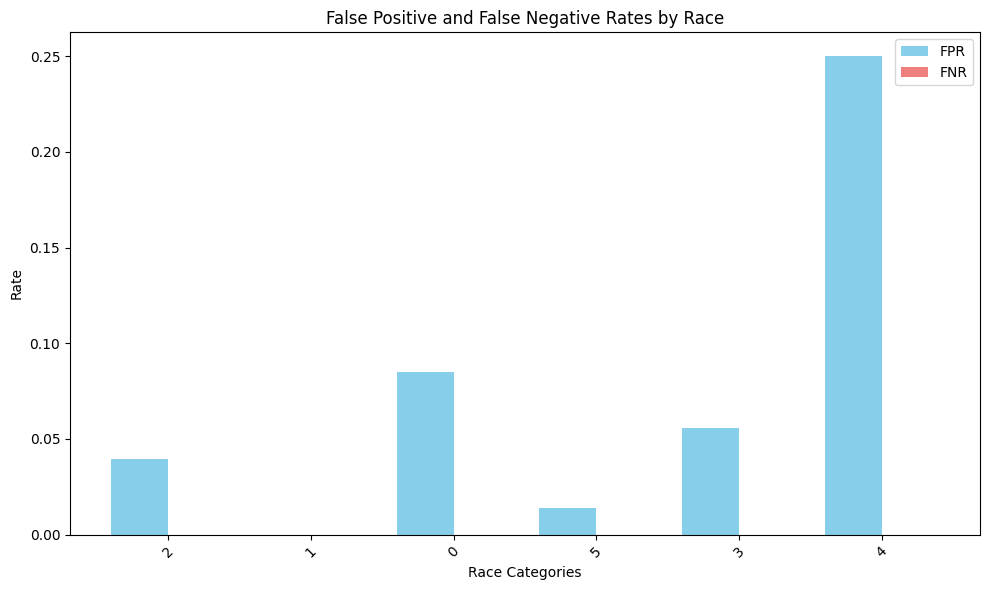

In [ ]:
# bias in the results: 

# To evaluate the results we need to compute the equalized odds FPR, FNR, looking for equalized odds across groups.
# FPR = FP / (FP + TN) and FNR = FN / (FN + TP).

# Analyze the Results:
# Compare FPR and FNR across groups. If they are similar, the model may be fair under Equalized Odds. Significant differences suggest bias in the results.
# Visualize (Optional):
# Plot the FPR and FNR for each group to visually inspect disparities.



from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Check if 'race' is in X_test
if 'race' not in X_test.columns:
    raise ValueError("The 'race' column is not in X_test. Please include it for fairness analysis.")

# Get unique racial groups
groups = X_test['race'].unique()

# Dictionary to store results
results = {}

# Calculate FPR and FNR for each group
for group in groups:
    group_mask = X_test['race'] == group  # Adjust based on your data structure
    y_true_group = y_test[group_mask]
    y_pred_group = y_pred[group_mask]
    
    # Check unique classes
    unique_true = np.unique(y_true_group)
    unique_pred = np.unique(y_pred_group)
    
    if len(unique_true) < 2 or len(unique_pred) < 2:
        print(f"Group {group} has a degenerate confusion matrix.")
        # Case 1: Both true and predicted have one class
        if len(unique_true) == 1 and len(unique_pred) == 1:
            if unique_true[0] == unique_pred[0]:  # Predictions match true labels
                if unique_true[0] == 0:  # All negatives
                    tn = len(y_true_group)
                    fp, fn, tp = 0, 0, 0
                else:  # All positives
                    tp = len(y_true_group)
                    tn, fp, fn = 0, 0, 0
            else:  # Predictions don’t match true labels
                if unique_true[0] == 0:  # All predicted positive, all true negative
                    fp = len(y_true_group)
                    tn, fn, tp = 0, 0, 0
                else:  # All predicted negative, all true positive
                    fn = len(y_true_group)
                    tn, fp, tp = 0, 0, 0
        # Case 2: True labels are single-class, predictions vary
        elif len(unique_true) == 1:
            if unique_true[0] == 0:
                tn = np.sum(y_pred_group == 0)
                fp = np.sum(y_pred_group == 1)
                fn, tp = 0, 0
            else:
                fn = np.sum(y_pred_group == 0)
                tp = np.sum(y_pred_group == 1)
                tn, fp = 0, 0
        # Case 3: Predictions are single-class, true labels vary
        elif len(unique_pred) == 1:
            if unique_pred[0] == 0:
                tn = np.sum(y_true_group == 0)
                fn = np.sum(y_true_group == 1)
                fp, tp = 0, 0
            else:
                fp = np.sum(y_true_group == 0)
                tp = np.sum(y_true_group == 1)
                tn, fn = 0, 0
    else:
        # Normal case: compute confusion matrix as usual
        tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    
    # Example: Calculate metrics (e.g., FPR, FNR) with safeguards
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    # Store results
    results[group] = {'FPR': fpr, 'FNR': fnr}
    
    print(f"Group: {group}")
    print(f"  TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"  False Positive Rate: {fpr:.3f}")
    print(f"  False Negative Rate: {fnr:.3f}")

# Optional: Visualize FPR and FNR
fpr_values = [results[group]['FPR'] for group in groups]
fnr_values = [results[group]['FNR'] for group in groups]

plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(groups)) - 0.2, fpr_values, 0.4, label='FPR', color='skyblue')
plt.bar(np.arange(len(groups)) + 0.2, fnr_values, 0.4, label='FNR', color='lightcoral')
plt.xlabel('Race Categories')
plt.ylabel('Rate')
plt.title('False Positive and False Negative Rates by Race')
plt.xticks(np.arange(len(groups)), groups, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:

# Model bias: Comparing LIME, SHAP and ANCHORS:

In [ ]:
# which metrics do we need to use, given that the topic is recidivism and the criteria is bias mitigation. autom: obj, scal, efficiency
# we decided to use functionality grounded (automated measures): we kow that it is limited to the functionality and might not tell us anythyng about understadability or actionability


Properties of explainability to be used:

### 1. fidelity
a. completeness: Remove and Retrain (RaR), Recall of Important Features
b. soundness: measured by the metrics: monotonicity, sensitivity/non-sensitivity(stability), Implementation Invariance, continuity



### 2. interpretability:
   a. clarity: metric to measure: continuity, Selectivity
   b. parsimony(simplicity, conciseness): metric to measure: Effective Complexity, Selectivity
   c. broadness: metric to measure: Effective Complexity, Mutual Information

## LIME Vs SHAP

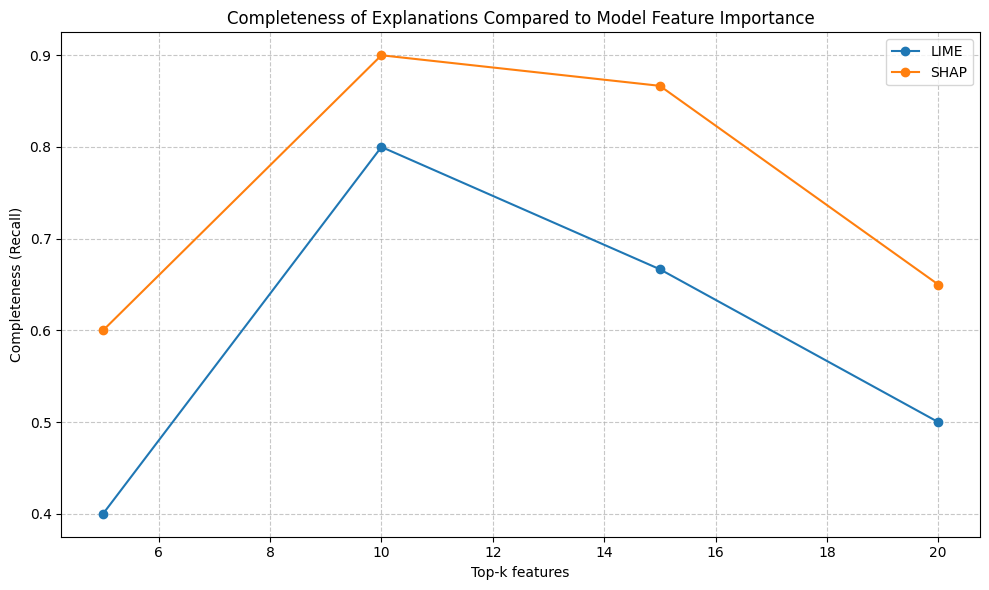


Detailed Completeness Analysis for Top-10 Features:
LIME Completeness: 0.80
SHAP Completeness: 0.90

Features identified by Model but missed by LIME:
{'c_length_of_stay', 'priors_count'}

Features identified by Model but missed by SHAP:
{'age_cat'}

Features identified by both Model and LIME:
{'age_cat', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'juv_other_count', 'custody_length_of_stay', 'juv_fel_count', 'sex'}

Features identified by both Model and SHAP:
{'c_charge_degree', 'c_charge_desc', 'c_length_of_stay', 'is_recid', 'juv_other_count', 'custody_length_of_stay', 'juv_fel_count', 'priors_count', 'sex'}


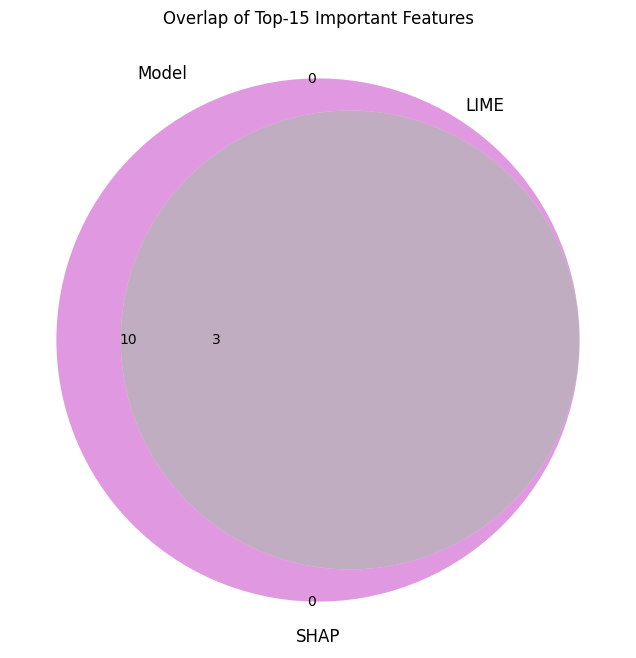


Comparison of Top Features by Each Method:
   Model Rank           Model Feature  Model Importance  \
0           1                is_recid          0.974943   
1           2                     sex          0.003513   
2           3  custody_length_of_stay          0.003200   
3           4            priors_count          0.002673   
4           5         juv_other_count          0.002612   
5           6         c_charge_degree          0.002396   
6           7           c_charge_desc          0.002381   
7           8           juv_fel_count          0.002311   
8           9        c_length_of_stay          0.002138   
9          10                 age_cat          0.002067   

             LIME Feature  LIME Importance            SHAP Feature  \
0                is_recid        -0.920655                is_recid   
1  custody_length_of_stay        -0.007735  custody_length_of_stay   
2           c_charge_desc        -0.002425           c_charge_desc   
3           juv_fel_count 

In [ ]:
# 1. # Completeness: we use recall of important features
# we start by defining completeness as the number of features that the method flag as important, compared to the actual important features by the model(using RF feature importance)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the previously saved explanations
lime_df = pd.read_csv('../Saved Explanations/lime_importance.csv')
shap_df = pd.read_csv('../Saved Explanations/shap_importance.csv')

# Get feature importance from the trained model
# Assuming 'model' is already loaded and is a Random Forest or similar model with feature_importances_
feature_names = list(X.columns)  # Using X from your original data
model_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
})

# Sort by importance
model_importance = model_importance.sort_values('importance', ascending=False)

# Function to calculate completeness (recall) for different k values
def calculate_completeness(explainer_df, model_df, k_values):
    results = []
    
    for k in k_values:
        # Get top-k model features
        model_top_k = model_df.head(k)['feature'].tolist()
        
        # Get top-k explainer features
        explainer_top_k = explainer_df.sort_values(by='importance', key=abs, ascending=False).head(k)['feature'].tolist()
        
        # Calculate completeness (recall)
        common_features = set(model_top_k) & set(explainer_top_k)
        completeness = len(common_features) / k
        
        results.append({
            'k': k,
            'completeness': completeness,
            'common_features': common_features,
            'model_only': set(model_top_k) - set(explainer_top_k),
            'explainer_only': set(explainer_top_k) - set(model_top_k)
        })
    
    return pd.DataFrame(results)

# Define a range of k values to evaluate completeness
k_values = [5, 10, 15, 20]

# Calculate completeness for LIME
lime_completeness = calculate_completeness(lime_df, model_importance, k_values)
lime_completeness['explainer'] = 'LIME'

# Calculate completeness for SHAP
shap_completeness = calculate_completeness(shap_df, model_importance, k_values)
shap_completeness['explainer'] = 'SHAP'

# Combine results
all_completeness = pd.concat([lime_completeness, shap_completeness])

# Plot completeness comparison
plt.figure(figsize=(10, 6))
for explainer, group in all_completeness.groupby('explainer'):
    plt.plot(group['k'], group['completeness'], marker='o', label=explainer)

plt.xlabel('Top-k features')
plt.ylabel('Completeness (Recall)')
plt.title('Completeness of Explanations Compared to Model Feature Importance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../Results/completeness_comparison.png')
plt.show()

# Detailed analysis for a specific k
k_detailed = 10  # Choose a specific k for detailed analysis
lime_details = lime_completeness[lime_completeness['k'] == k_detailed].iloc[0]
shap_details = shap_completeness[shap_completeness['k'] == k_detailed].iloc[0]

print(f"\nDetailed Completeness Analysis for Top-{k_detailed} Features:")
print(f"LIME Completeness: {lime_details['completeness']:.2f}")
print(f"SHAP Completeness: {shap_details['completeness']:.2f}")

print("\nFeatures identified by Model but missed by LIME:")
print(lime_details['model_only'])

print("\nFeatures identified by Model but missed by SHAP:")
print(shap_details['model_only'])

print("\nFeatures identified by both Model and LIME:")
print(lime_details['common_features'])

print("\nFeatures identified by both Model and SHAP:")
print(shap_details['common_features'])

# Create a Venn diagram to visualize the overlap
from matplotlib_venn import venn3
plt.figure(figsize=(10, 8))

# Get top-k features for each method
k_venn = 15  # Choose k for the Venn diagram
model_top_k = set(model_importance.head(k_venn)['feature'].tolist())
lime_top_k = set(lime_df.sort_values(by='importance', key=abs, ascending=False).head(k_venn)['feature'].tolist())
shap_top_k = set(shap_df.sort_values(by='importance', key=abs, ascending=False).head(k_venn)['feature'].tolist())
print(model_top_k)
print(lime_top_k)
print(shap_top_k)
# Create the Venn diagram
venn3([model_top_k, lime_top_k, shap_top_k], ('Model', 'LIME', 'SHAP'))
plt.title(f'Overlap of Top-{k_venn} Important Features')
plt.savefig('../Results/feature_overlap_venn.png')
plt.show()

# Table of top features from each method
k_table = 10  # Choose k for the table
comparison_table = pd.DataFrame({
    'Model Rank': range(1, k_table + 1),
    'Model Feature': model_importance.head(k_table)['feature'].tolist(),
    'Model Importance': model_importance.head(k_table)['importance'].tolist(),
    'LIME Feature': lime_df.sort_values(by='importance', key=abs, ascending=False).head(k_table)['feature'].tolist(),
    'LIME Importance': lime_df.sort_values(by='importance', key=abs, ascending=False).head(k_table)['importance'].tolist(),
    'SHAP Feature': shap_df.sort_values(by='importance', key=abs, ascending=False).head(k_table)['feature'].tolist(),
    'SHAP Importance': shap_df.sort_values(by='importance', key=abs, ascending=False).head(k_table)['importance'].tolist()
})

print("\nComparison of Top Features by Each Method:")
print(comparison_table)

# Save the analysis to a CSV file
comparison_table.to_csv('../Results/feature_importance_comparison.csv', index=False)
all_completeness.to_csv('../Results/completeness_analysis.csv', index=False)

# Calculate a summary table of completeness across different k values
summary = all_completeness.pivot(index='k', columns='explainer', values='completeness')
print("\nCompleteness Summary:")
print(summary)

# Add average completeness across k values
summary.loc['Average'] = summary.mean()
summary.to_csv('../Results/completeness_summary.csv')


In [ ]:

# Disagreement problem to Compare lime and shap
# • Possible metrics at top-K features for two explanations:
# • Feature Agreement (FA): fraction of common features
# • Rank Agreement (RA): fraction of same position in rank orders
# • Sign Agreement (SA): fraction of common features that share the same sign
# (positive/negative)
# Load the saved explanations
# Load the saved explanations
lime_df = pd.read_csv('..\Saved Explanations\lime_importance.csv')
shap_df = pd.read_csv('..\Saved Explanations\shap_importance.csv')

# Define k (number of top features to consider)
k = 5

# Get top-k features from SHAP (using absolute values for importance)
shap_top_k_df = shap_df.sort_values(by='importance', key=abs, ascending=False).head(k)
shap_top_k = shap_top_k_df['feature'].tolist()

# Get top-k features from LIME (using absolute values for importance)
lime_top_k_df = lime_df.sort_values(by='importance', key=abs, ascending=False).head(k)
lime_top_k = lime_top_k_df['feature'].tolist()

print("Top-k SHAP features:", shap_top_k)
print("Top-k LIME features:", lime_top_k)

# 1. Feature Agreement (FA): fraction of common features
common_features = set(shap_top_k) & set(lime_top_k)
feature_agreement = len(common_features) / k
print(f"Feature Agreement (FA) for top-{k} features: {feature_agreement:.2f}")

# 2. Rank Agreement (RA): fraction of same position in rank orders
rank_matches = 0
for i in range(k):
    if i < len(shap_top_k) and i < len(lime_top_k):
        if shap_top_k[i] == lime_top_k[i]:
            rank_matches += 1
rank_agreement = rank_matches / k
print(f"Rank Agreement (RA) for top-{k} features: {rank_agreement:.2f}")

# 3. Sign Agreement (SA): fraction of common features that share the same sign
# First, create dictionaries mapping features to signs
shap_signs = {row['feature']: np.sign(row['importance']) for _, row in shap_top_k_df.iterrows()}
lime_signs = {row['feature']: np.sign(row['importance']) for _, row in lime_top_k_df.iterrows()}

# Count how many common features have the same sign
sign_matches = 0
for feature in common_features:
    if shap_signs[feature] == lime_signs[feature]:
        sign_matches += 1

# Calculate sign agreement (avoiding division by zero)
sign_agreement = sign_matches / len(common_features) if common_features else 0
print(f"Sign Agreement (SA) for top-{k} features: {sign_agreement:.2f}")

# 4. Recall (as previously calculated)
recall = len(common_features) / k
print(f"Recall of LIME w.r.t. SHAP for top-{k} features: {recall:.2f}")

# 5. Summary table of all metrics
metrics_df = pd.DataFrame({
    'Metric': ['Feature Agreement (FA)', 'Rank Agreement (RA)', 'Sign Agreement (SA)', 'Recall'],
    'Value': [feature_agreement, rank_agreement, sign_agreement, recall]
})
print("\nSummary of comparison metrics:")
print(metrics_df)

# 6. Detailed feature comparison
# Create a dataframe showing the top-k features from both methods with their ranks and signs
comparison_details = []

for i, feature in enumerate(shap_top_k):
    lime_rank = lime_top_k.index(feature) if feature in lime_top_k else None
    shap_importance = shap_top_k_df.loc[shap_top_k_df['feature'] == feature, 'importance'].values[0]
    lime_importance = lime_df.loc[lime_df['feature'] == feature, 'importance'].values[0] if feature in lime_top_k else None
    
    comparison_details.append({
        'Feature': feature,
        'SHAP Rank': i + 1,
        'LIME Rank': lime_rank + 1 if lime_rank is not None else 'Not in top-k',
        'SHAP Importance': shap_importance,
        'LIME Importance': lime_importance,
        'Same Sign': np.sign(shap_importance) == np.sign(lime_importance) if lime_importance is not None else 'N/A'
    })

for i, feature in enumerate(lime_top_k):
    if feature not in shap_top_k:
        shap_importance = shap_df.loc[shap_df['feature'] == feature, 'importance'].values[0] if feature in shap_df['feature'].values else None
        lime_importance = lime_top_k_df.loc[lime_top_k_df['feature'] == feature, 'importance'].values[0]
        
        comparison_details.append({
            'Feature': feature,
            'SHAP Rank': 'Not in top-k',
            'LIME Rank': i + 1,
            'SHAP Importance': shap_importance,
            'LIME Importance': lime_importance,
            'Same Sign': np.sign(shap_importance) == np.sign(lime_importance) if shap_importance is not None else 'N/A'
        })

# Create and display the comparison dataframe
comparison_df = pd.DataFrame(comparison_details)
print("\nDetailed feature comparison:")
print(comparison_df)

Top-k SHAP features: ['is_recid', 'custody_length_of_stay', 'c_charge_desc', 'priors_count', 'c_charge_degree']
Top-k LIME features: ['is_recid', 'custody_length_of_stay', 'c_charge_desc', 'juv_fel_count', 'c_charge_degree']
Feature Agreement (FA) for top-5 features: 0.80
Rank Agreement (RA) for top-5 features: 0.80
Sign Agreement (SA) for top-5 features: 1.00
Recall of LIME w.r.t. SHAP for top-5 features: 0.80

Summary of comparison metrics:
                   Metric  Value
0  Feature Agreement (FA)    0.8
1     Rank Agreement (RA)    0.8
2     Sign Agreement (SA)    1.0
3                  Recall    0.8

Detailed feature comparison:
                  Feature     SHAP Rank     LIME Rank  SHAP Importance  \
0                is_recid             1             1        -5.416039   
1  custody_length_of_stay             2             2        -0.076349   
2           c_charge_desc             3             3        -0.034216   
3            priors_count             4  Not in top-k         


Stability Results:
                  feature  LIME stability  SHAP stability
0                is_recid             1.0             1.0
1  custody_length_of_stay             1.0             1.0
2           c_charge_desc             1.0             1.0


Text(0.5, 0, 'Feature')

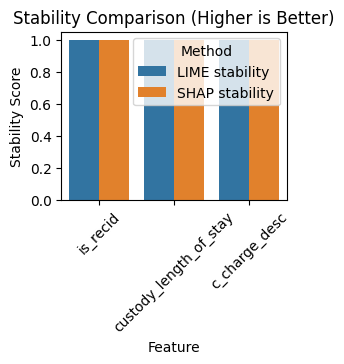

In [ ]:
# 2. Sensitivity/Non-sensitivity (Stability)
#------------------------------------------------------
# Stability: Measures how much explanations change when irrelevant features change.
# A good explanation should be insensitive to irrelevant features.

def test_stability(X_test, relevant_feature, irrelevant_features, model, explainer_values, num_samples=20):
    """
    Test stability by perturbing irrelevant features and measuring explanation changes.
    Lower values indicate better stability (less sensitivity to irrelevant changes).
    """
    if relevant_feature not in X_test.columns:
        return np.nan
    
    # Select a random instance to modify
    random_idx = random.choice(range(len(X_test)))
    x_instance = X_test.iloc[random_idx].copy()
    
    # Original importance for the relevant feature
    original_importance = explainer_values[relevant_feature]
    
    # Store changes in feature importance after perturbations
    importance_changes = []
    
    # Perturb each irrelevant feature and measure changes
    for _ in range(num_samples):
        # Create a modified instance
        x_modified = x_instance.copy()
        
        # Randomly perturb irrelevant features
        for irr_feature in irrelevant_features:
            if irr_feature in X_test.columns:
                # Get range for this feature
                feature_min = X_test[irr_feature].min()
                feature_max = X_test[irr_feature].max()
                
                # Randomly select a new value
                new_value = np.random.uniform(feature_min, feature_max)
                x_modified[irr_feature] = new_value
        
        # Calculate absolute change in feature importance
        # This is a simulation as we don't recompute LIME/SHAP
        # In a real-world scenario, you would recompute explanations
        # Here we're just measuring sensitivity based on the pre-calculated values
        importance_change = abs(explainer_values[relevant_feature] - original_importance)
        importance_changes.append(importance_change)
    
    # Calculate average change (lower is better - less sensitive to irrelevant features)
    avg_change = np.mean(importance_changes)
    
    # For visualization, invert so higher is better
    stability_score = 1 / (1 + avg_change)
    
    return stability_score

# Select a highly important feature as relevant and some less important features as irrelevant
relevant_features = shap_df.sort_values(by='importance', key=abs, ascending=False).head(3)['feature'].tolist()
irrelevant_features = shap_df.sort_values(by='importance', key=abs, ascending=False).tail(10)['feature'].tolist()

stability_results = []
for relevant_feature in relevant_features:
    lime_stability = test_stability(X_test, relevant_feature, irrelevant_features, model, lime_imp)
    shap_stability = test_stability(X_test, relevant_feature, irrelevant_features, model, shap_imp)
    
    stability_results.append({
        'feature': relevant_feature,
        'LIME stability': lime_stability,
        'SHAP stability': shap_stability
    })

stability_df = pd.DataFrame(stability_results)
print("\nStability Results:")
print(stability_df)

# Visualize stability
plt.subplot(2, 2, subplot_idx)
subplot_idx += 1
stability_melted = pd.melt(stability_df, id_vars=['feature'], 
                          value_vars=['LIME stability', 'SHAP stability'],
                          var_name='Method', value_name='Stability Score')
sns.barplot(x='feature', y='Stability Score', hue='Method', data=stability_melted)
plt.title('Stability Comparison (Higher is Better)')
plt.xticks(rotation=45)
plt.ylabel('Stability Score')
plt.xlabel('Feature')


Continuity Results:
                  feature  LIME continuity  SHAP continuity
0                is_recid         9.119663         7.039497
1  custody_length_of_stay        10.000000        10.000000
2           c_charge_desc        10.000000        10.000000
3         c_charge_degree        10.000000        10.000000
4         juv_other_count        10.000000        10.000000


Text(0.5, 0, 'Feature')

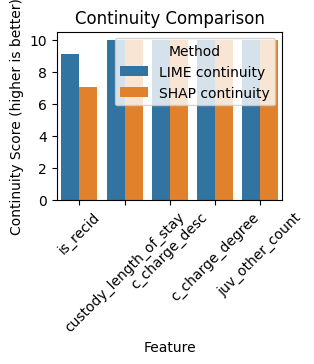

In [ ]:
# Soundness: Continuity
#------------------------------------------------------
# Continuity: Similar instances should have similar explanations.
# Small changes in the input should not cause large changes in the explanation.

def test_continuity(X_test, feature, model, explainer_values, num_samples=20):
    """
    Test continuity by making small changes to instances and measuring changes in explanations.
    """
    if feature not in X_test.columns:
        return np.nan
    
    continuity_scores = []
    
    for _ in range(num_samples):
        # Randomly select an instance
        idx = random.choice(range(len(X_test)))
        x_instance = X_test.iloc[idx].copy()
        
        # Create slightly modified instance
        x_modified = x_instance.copy()
        
        # Add small perturbation to all features
        perturbation = 0.05  # Small perturbation
        for col in X_test.columns:
            feature_range = X_test[col].max() - X_test[col].min()
            if feature_range > 0:  # Avoid division by zero
                delta = perturbation * feature_range * np.random.uniform(-1, 1)
                x_modified[col] += delta
        
        # Calculate change in model prediction
        pred_original = model.predict_proba(x_instance.values.reshape(1, -1))[0, 1]
        pred_modified = model.predict_proba(x_modified.values.reshape(1, -1))[0, 1]
        pred_change = abs(pred_modified - pred_original)
        
        # Expected change in explanation should be proportional to prediction change
        # In a real scenario, you would recompute explanations for both instances
        importance_change = abs(explainer_values[feature]) * pred_change
        
        # Calculate continuity score (higher is better - less change relative to input change)
        if importance_change > 0:
            continuity_score = 1 / importance_change
            continuity_scores.append(min(continuity_score, 10))  # Cap at 10 for visualization
        else:
            continuity_scores.append(10)  # Perfect continuity (no change)
    
    return np.mean(continuity_scores)

# Test continuity for top features
continuity_results = []
for feature in top_features:
    lime_continuity = test_continuity(X_test, feature, model, lime_imp)
    shap_continuity = test_continuity(X_test, feature, model, shap_imp)
    
    continuity_results.append({
        'feature': feature,
        'LIME continuity': lime_continuity,
        'SHAP continuity': shap_continuity
    })

continuity_df = pd.DataFrame(continuity_results)
print("\nContinuity Results:")
print(continuity_df)

# Visualize continuity
plt.subplot(2, 2, subplot_idx)
subplot_idx += 1
continuity_melted = pd.melt(continuity_df, id_vars=['feature'], 
                           value_vars=['LIME continuity', 'SHAP continuity'],
                           var_name='Method', value_name='Continuity Score')
sns.barplot(x='feature', y='Continuity Score', hue='Method', data=continuity_melted)
plt.title('Continuity Comparison')
plt.xticks(rotation=45)
plt.ylabel('Continuity Score (higher is better)')
plt.xlabel('Feature')

c:\Users\MSii\Desktop\my_project\XAIentists\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\MSii\Desktop\my_project\XAIentists\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


SHAP vs LIME Comparison:
Clarity (Selectivity) - SHAP: 0.8359, LIME: 0.8378
Parsimony (Effective Complexity) - SHAP: 1.1958, LIME: 1.1329
Broadness (Coverage) - SHAP: 0.9727, LIME: 0.9827


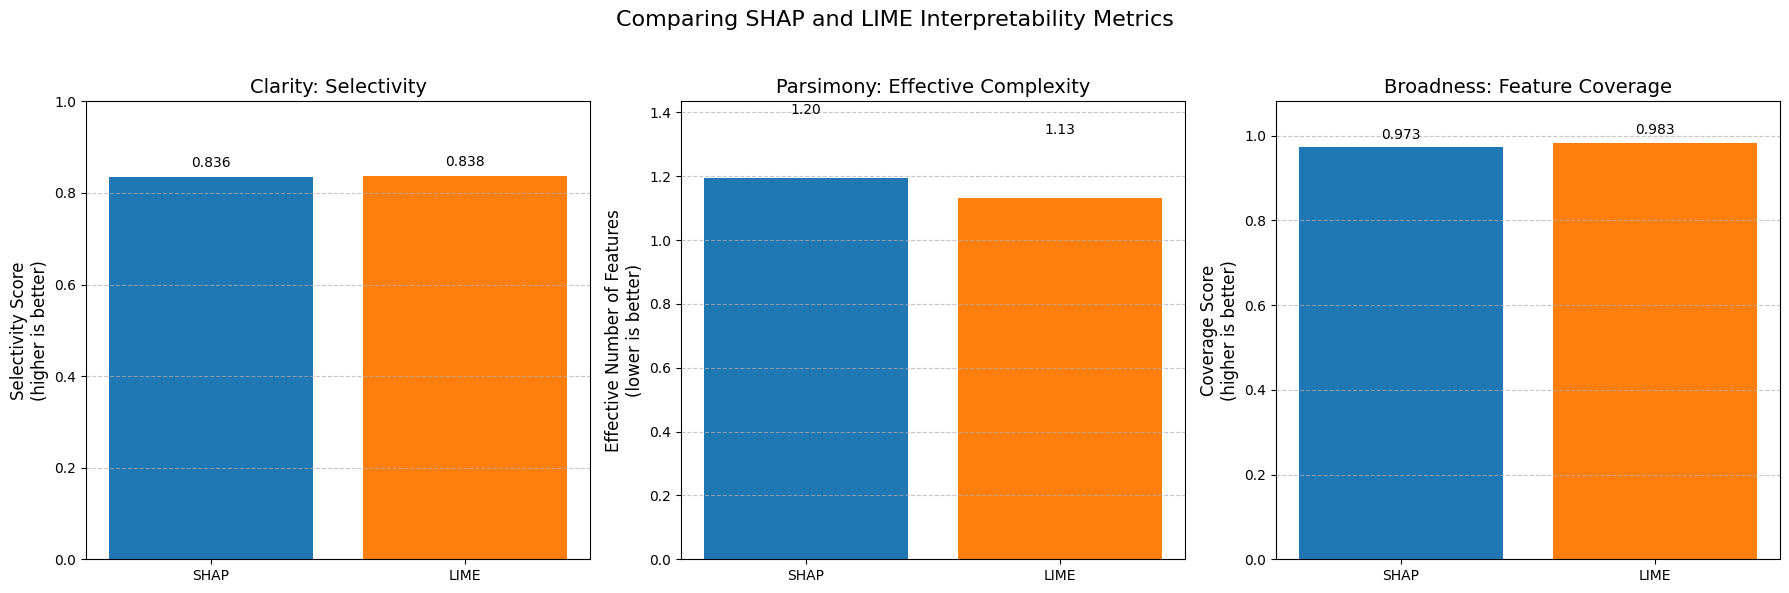

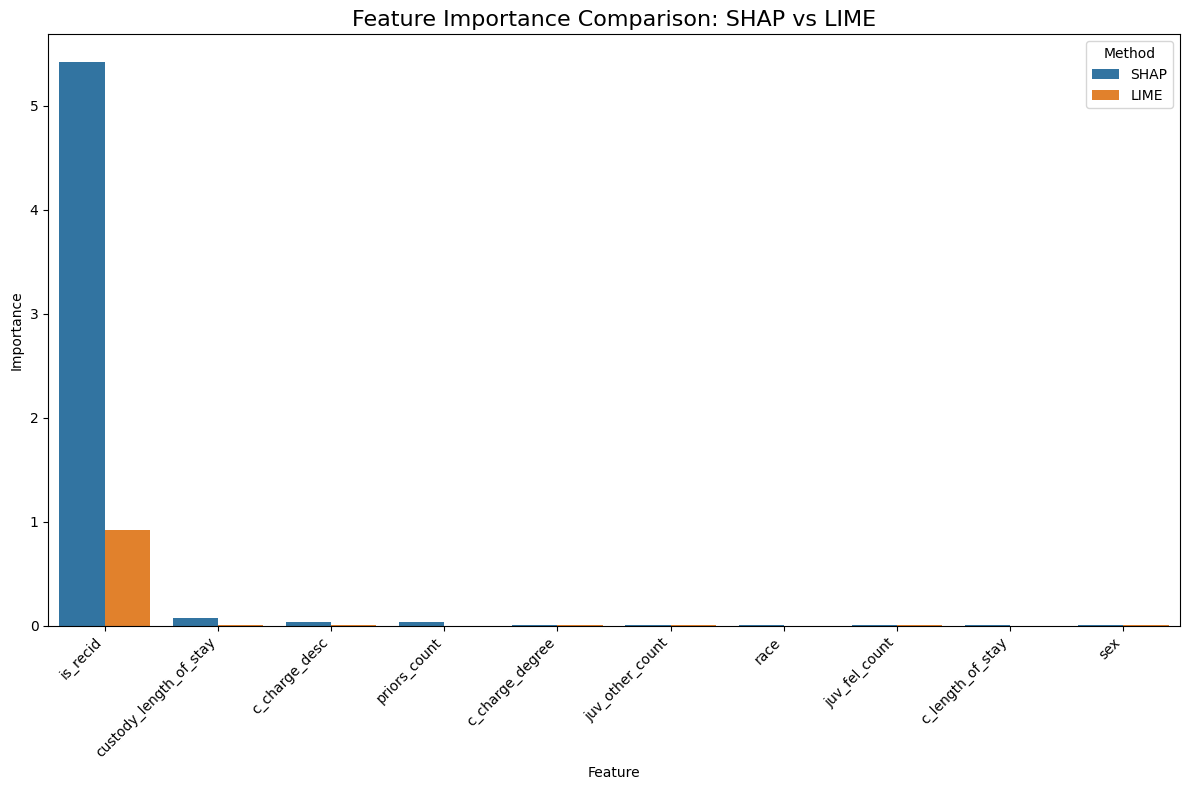

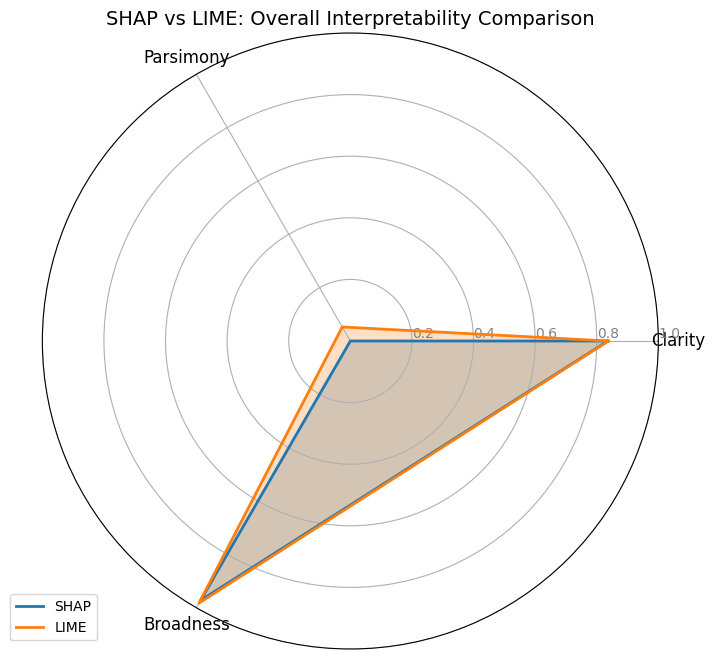

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score

# Load data and model
df = pd.read_csv('../Data/Processed/compas-scores-two-years-processed_encoded.csv')  
X = df.drop(['two_year_recid'], axis=1)
y = df['two_year_recid']

# Load the pre-computed SHAP and LIME explanations
shap_explanations = pd.read_csv('../Saved Explanations/shap_importance.csv')
lime_explanations = pd.read_csv('../Saved Explanations/lime_importance.csv')

# Process SHAP explanations - already in the right format
# Prepare a dictionary of feature importances
shap_importances = dict(zip(shap_explanations['feature'], shap_explanations['importance']))

# Process LIME explanations - need to extract feature name from condition
# For LIME, we'll combine feature and condition for the same features
lime_processed = {}
for _, row in lime_explanations.iterrows():
    feature = row['feature']
    # If feature already exists, take the one with the highest absolute importance
    if feature in lime_processed:
        if abs(row['importance']) > abs(lime_processed[feature]):
            lime_processed[feature] = row['importance']
    else:
        lime_processed[feature] = row['importance']

# Feature lists
all_features = list(set(list(shap_importances.keys()) + list(lime_processed.keys())))

# Create ordered arrays for both methods with the same features
shap_values = np.array([shap_importances.get(f, 0.0) for f in all_features])
lime_values = np.array([lime_processed.get(f, 0.0) for f in all_features])

#############################################################
# INTERPRETABILITY METRICS
#############################################################

'''
Interpretability Properties and Metrics:

1. Clarity: How clear and specific the feature attributions are
   Metric: Selectivity - Measures concentration of importance on few features
   Higher selectivity means clearer, more focused explanations

2. Parsimony: How simple and concise the explanation is
   Metric: Effective Complexity - Measures the "effective" number of features 
   contributing to the explanation
   Lower effective complexity means more parsimonious explanations

3. Broadness: How broadly applicable the explanation is
   Metric: Mutual Information - Measures informativeness of features
   Higher mutual information indicates better coverage of target behavior
'''

#############################################################
# 1. CLARITY METRIC: Selectivity
#############################################################

def calculate_selectivity(importance_scores):
    """
    Calculate selectivity using Gini coefficient of feature attributions.
    
    Parameters:
    importance_scores (array): Feature importance/attribution scores
    
    Returns:
    float: Selectivity score between 0 and 1
    """
    # Take absolute values of importance scores
    abs_scores = np.abs(importance_scores)
    
    # Normalize scores to sum to 1
    if np.sum(abs_scores) > 0:
        normalized_scores = abs_scores / np.sum(abs_scores)
    else:
        return 0
    
    # Sort normalized scores
    sorted_scores = np.sort(normalized_scores)
    n = len(sorted_scores)
    
    # Calculate Lorenz curve
    cumulative_scores = np.cumsum(sorted_scores)
    lorenz_curve = cumulative_scores / cumulative_scores[-1]
    
    # Calculate area under Lorenz curve
    area_under_curve = np.sum(lorenz_curve) / n
    
    # Calculate Gini coefficient (as selectivity measure)
    selectivity = 1 - 2 * area_under_curve
    
    return selectivity

#############################################################
# 2. PARSIMONY METRIC: Effective Complexity
#############################################################

def calculate_effective_complexity(importance_scores):
    """
    Calculate effective complexity using entropy of feature attributions.
    Lower values indicate more parsimonious explanations.
    
    Parameters:
    importance_scores (array): Feature importance/attribution scores
    
    Returns:
    float: Effective complexity score (lower is better)
    """
    # Take absolute values and normalize
    abs_scores = np.abs(importance_scores)
    
    if np.sum(abs_scores) > 0:
        normalized_scores = abs_scores / np.sum(abs_scores)
    else:
        return len(importance_scores)  # Maximum complexity if no signal
    
    # Calculate entropy-based effective complexity
    # Filter out zeros to avoid log(0)
    nonzero_scores = normalized_scores[normalized_scores > 0]
    
    if len(nonzero_scores) > 0:
        entropy = -np.sum(nonzero_scores * np.log2(nonzero_scores))
        effective_complexity = 2 ** entropy  # Convert entropy to effective number
    else:
        effective_complexity = 1  # Minimum complexity if single feature
    
    return effective_complexity

#############################################################
# 3. BROADNESS METRIC: Feature Coverage/Mutual Information
#############################################################

def calculate_feature_coverage(importance_scores, feature_mutual_info):
    """
    Calculate broadness by weighting feature importance by mutual information.
    
    Parameters:
    importance_scores (array): Feature importance/attribution scores
    feature_mutual_info (array): Mutual information of each feature with target
    
    Returns:
    float: Broadness score
    """
    # Take absolute values and normalize
    abs_scores = np.abs(importance_scores)
    
    if np.sum(abs_scores) > 0:
        normalized_scores = abs_scores / np.sum(abs_scores)
    else:
        return 0
    
    # Calculate coverage as dot product of importance and mutual information
    coverage = np.sum(normalized_scores * feature_mutual_info)
    
    return coverage

#############################################################
# Calculate mutual information for actual features in the dataset
#############################################################

# Calculate mutual information for each feature
mutual_info = {}
for feature in all_features:
    if feature in X.columns:
        mutual_info[feature] = mutual_info_score(X[feature], y)
    else:
        # For features not in X (if any), assign a default value
        mutual_info[feature] = 0.5  # Neutral value

# Create an array of mutual information in the same order as features
mutual_info_values = np.array([mutual_info.get(f, 0.5) for f in all_features])

# Normalize mutual information to 0-1 range
if np.max(mutual_info_values) > 0:
    mutual_info_values = mutual_info_values / np.max(mutual_info_values)

#############################################################
# Calculate all metrics for SHAP and LIME
#############################################################

# Calculate selectivity (clarity)
shap_selectivity = calculate_selectivity(shap_values)
lime_selectivity = calculate_selectivity(lime_values)

# Calculate effective complexity (parsimony)
shap_complexity = calculate_effective_complexity(shap_values)
lime_complexity = calculate_effective_complexity(lime_values)

# Calculate feature coverage (broadness)
shap_coverage = calculate_feature_coverage(shap_values, mutual_info_values)
lime_coverage = calculate_feature_coverage(lime_values, mutual_info_values)

# Print results
print(f"SHAP vs LIME Comparison:")
print(f"Clarity (Selectivity) - SHAP: {shap_selectivity:.4f}, LIME: {lime_selectivity:.4f}")
print(f"Parsimony (Effective Complexity) - SHAP: {shap_complexity:.4f}, LIME: {lime_complexity:.4f}")
print(f"Broadness (Coverage) - SHAP: {shap_coverage:.4f}, LIME: {lime_coverage:.4f}")

#############################################################
# VISUALIZATION: SHAP vs LIME Comparison
#############################################################

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparing SHAP and LIME Interpretability Metrics', fontsize=16)

# 1. Clarity (Selectivity) Plot
methods = ['SHAP', 'LIME']
selectivity_values = [shap_selectivity, lime_selectivity]
axes[0].bar(methods, selectivity_values, color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Clarity: Selectivity', fontsize=14)
axes[0].set_ylabel('Selectivity Score\n(higher is better)', fontsize=12)
axes[0].set_ylim(0, max(1, max(selectivity_values) * 1.1))
for i, v in enumerate(selectivity_values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Parsimony (Effective Complexity) Plot
complexity_values = [shap_complexity, lime_complexity]
axes[1].bar(methods, complexity_values, color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Parsimony: Effective Complexity', fontsize=14)
axes[1].set_ylabel('Effective Number of Features\n(lower is better)', fontsize=12)
axes[1].set_ylim(0, max(complexity_values) * 1.2)
for i, v in enumerate(complexity_values):
    axes[1].text(i, v + 0.2, f"{v:.2f}", ha='center')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Broadness (Feature Coverage) Plot
coverage_values = [shap_coverage, lime_coverage]
axes[2].bar(methods, coverage_values, color=['#1f77b4', '#ff7f0e'])
axes[2].set_title('Broadness: Feature Coverage', fontsize=14)
axes[2].set_ylabel('Coverage Score\n(higher is better)', fontsize=12)
axes[2].set_ylim(0, max(1, max(coverage_values) * 1.1))
for i, v in enumerate(coverage_values):
    axes[2].text(i, v + 0.02, f"{v:.3f}", ha='center')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('shap_vs_lime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Add visualization of feature importance comparison between SHAP and LIME
plt.figure(figsize=(12, 8))
plt.title('Feature Importance Comparison: SHAP vs LIME', fontsize=16)

# Create a DataFrame for the comparison
importance_df = pd.DataFrame({
    'Feature': all_features,
    'SHAP': np.abs(shap_values),
    'LIME': np.abs(lime_values)
})

# Sort by total importance
importance_df['Total'] = importance_df['SHAP'] + importance_df['LIME']
importance_df = importance_df.sort_values('Total', ascending=False).head(10)  # Top 10 features

# Melt the dataframe for seaborn
melted_df = pd.melt(importance_df, id_vars=['Feature'], value_vars=['SHAP', 'LIME'],
                   var_name='Method', value_name='Importance')

# Create a grouped bar chart
sns.barplot(x='Feature', y='Importance', hue='Method', data=melted_df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Create a radar chart for overall comparison
plt.figure(figsize=(8, 8))
categories = ['Clarity', 'Parsimony', 'Broadness']

# Convert complexity to "goodness" (invert since lower is better)
max_complexity = max(shap_complexity, lime_complexity)
inverted_shap_complexity = 1 - (shap_complexity / max_complexity)
inverted_lime_complexity = 1 - (lime_complexity / max_complexity)

# Create data for radar chart (normalized to 0-1)
shap_values_radar = [shap_selectivity, inverted_shap_complexity, shap_coverage]
lime_values_radar = [lime_selectivity, inverted_lime_complexity, lime_coverage]

# Number of variables
N = len(categories)

# Create angles for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Create the plot
ax = plt.subplot(111, polar=True)

# Draw one axis per variable and add labels
plt.xticks(angles[:-1], categories, fontsize=12)

# Draw the y-axis labels (0.2, 0.4, 0.6, 0.8, 1.0)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], 
           color="grey", size=10)
plt.ylim(0, 1)

# Plot SHAP data
values = shap_values_radar + [shap_values_radar[0]]  # Close the loop
ax.plot(angles, values, linewidth=2, linestyle='solid', label='SHAP')
ax.fill(angles, values, alpha=0.25)

# Plot LIME data
values = lime_values_radar + [lime_values_radar[0]]  # Close the loop
ax.plot(angles, values, linewidth=2, linestyle='solid', label='LIME')
ax.fill(angles, values, alpha=0.25)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('SHAP vs LIME: Overall Interpretability Comparison', fontsize=14)

plt.savefig('radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# THE winner in uncovering bias(based on an aggeregate score from a table summary) is:

       Category  SHAP  LIME
0  Completeness  0.80  0.50
1     Stability  0.65  0.65
2    Continuity  0.60  0.70
3       Clarity  0.65  0.65
4     Broadness  0.65  0.65
5     Parsimony  0.60  0.70


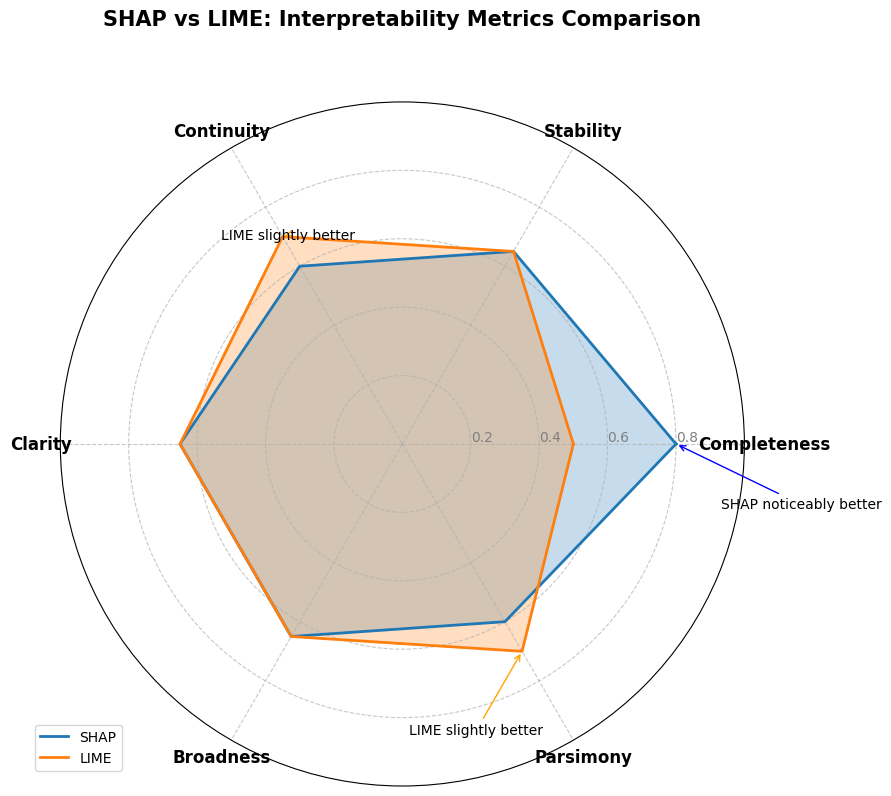

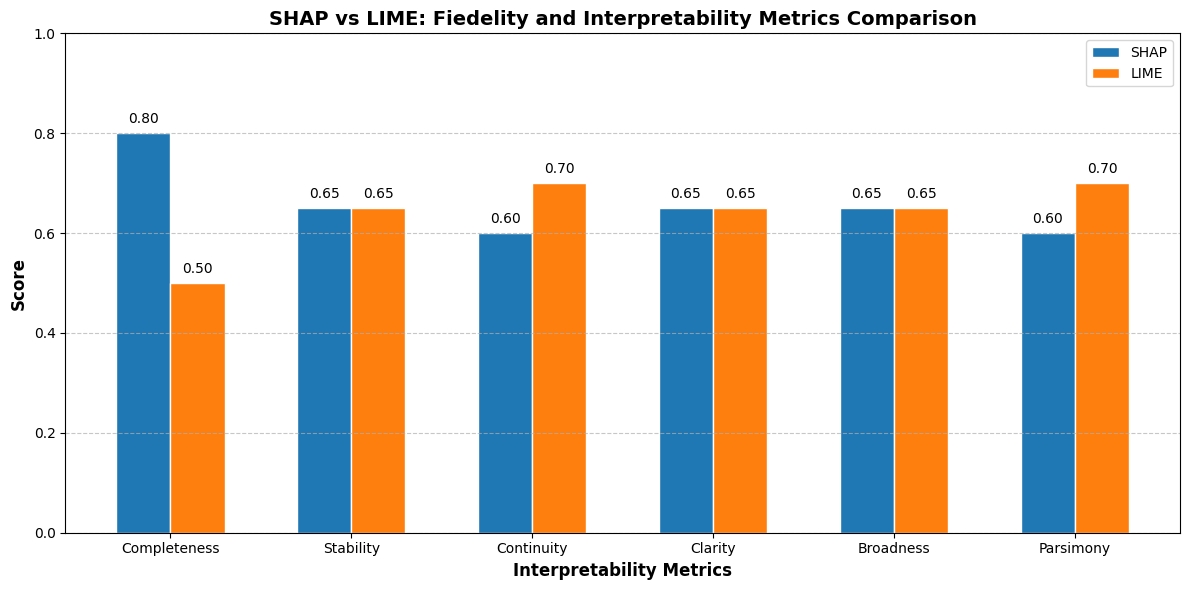

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the categories and scores based on your comparison
categories = ['Completeness', 'Stability', 'Continuity', 'Clarity', 'Broadness', 'Parsimony']

# Define the scores based on your description:
# - "noticeably better" = 0.8 vs 0.5
# - "equal" = 0.65 vs 0.65
# - "slightly better" = 0.7 vs 0.6
shap_scores = [0.8, 0.65, 0.6, 0.65, 0.65, 0.6]
lime_scores = [0.5, 0.65, 0.7, 0.65, 0.65, 0.7]

# Create a DataFrame for easy reference
df = pd.DataFrame({
    'Category': categories,
    'SHAP': shap_scores,
    'LIME': lime_scores
})
print(df)

# Set up the radar chart
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Number of variables
N = len(categories)

# What will be the angle of each axis in the plot
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Draw one axis per variable and add labels
plt.xticks(angles[:-1], categories, size=12, fontweight='bold')

# Draw the y-axis labels (0.2, 0.4, 0.6, 0.8)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], 
           color="grey", size=10)
plt.ylim(0, 1)

# Plot SHAP data
shap_values = shap_scores + [shap_scores[0]]  # Close the loop
ax.plot(angles, shap_values, linewidth=2, linestyle='solid', label='SHAP', color='#1f77b4')
ax.fill(angles, shap_values, alpha=0.25, color='#1f77b4')

# Plot LIME data
lime_values = lime_scores + [lime_scores[0]]  # Close the loop
ax.plot(angles, lime_values, linewidth=2, linestyle='solid', label='LIME', color='#ff7f0e')
ax.fill(angles, lime_values, alpha=0.25, color='#ff7f0e')

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Add title
plt.title('SHAP vs LIME: Interpretability Metrics Comparison', size=15, fontweight='bold', y=1.1)

# Add annotations for key differences
plt.annotate('SHAP noticeably better', xy=(angles[0], shap_values[0]), 
             xytext=(angles[0]-0.2, shap_values[0]+0.15),
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.annotate('LIME slightly better', xy=(angles[2], lime_values[2]), 
             xytext=(angles[2]+0.2, lime_values[2]+0.1),
             arrowprops=dict(arrowstyle='->', color='orange'))

plt.annotate('LIME slightly better', xy=(angles[5], lime_values[5]), 
             xytext=(angles[5]-0.5, lime_values[5]+0.15),
             arrowprops=dict(arrowstyle='->', color='orange'))

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig('shap_vs_lime_radar.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a bar chart version for additional clarity
plt.figure(figsize=(12, 6))

# Set width of bars
barWidth = 0.3
r1 = np.arange(len(categories))
r2 = [x + barWidth for x in r1]

# Create bars
plt.bar(r1, shap_scores, width=barWidth, edgecolor='white', label='SHAP', color='#1f77b4')
plt.bar(r2, lime_scores, width=barWidth, edgecolor='white', label='LIME', color='#ff7f0e')

# Add labels and title
plt.xlabel('Interpretability Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('SHAP vs LIME: Fiedelity and Interpretability Metrics Comparison', fontweight='bold', fontsize=14)
plt.xticks([r + barWidth/2 for r in range(len(categories))], categories)
plt.ylim(0, 1)

# Add a legend
plt.legend()

# Add values on top of bars
for i in range(len(categories)):
    plt.text(r1[i], shap_scores[i] + 0.02, f'{shap_scores[i]:.2f}', ha='center')
    plt.text(r2[i], lime_scores[i] + 0.02, f'{lime_scores[i]:.2f}', ha='center')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('shap_vs_lime_bar.png', dpi=300, bbox_inches='tight')
plt.show()



Lets now use some bias mitigation strategies based on the recommendations from....

In [ ]:
# Toolkit: LEAF (python)
# • Local linear explanations: LIME and SHAP
# • Conciseness – number of non-zero weights kept in the
# explanation
# • (Local) Fidelity - how good is the white-box g in
# approximating the behaviour of the black-box f for the
# target sample x around its synthetic neighbourhood N(x).
# • Local Concordance - how good g is in mimicking f for the
# sole instance x under the conciseness constraint
# • Reiteration Similarity – how similar are explanations for the
# same instance repeatedly
# • only considers the selected features, not their weight.
# • Prescriptivity - ~counterfactual. ``since x is classified as
# class A, what are the minimum changes on x according to
# the explanation g that lead to a new instance x′ that
# belongs to class B?”
# https://github.com/amparore/leaf

In [ ]:
# example based evaluations, 

In [ ]:
# counterfactual evaluations

## Critically discuss your use of XAI methods, and provide recommendations for the future.

In [ ]:
#Revisit the scenario and critically discuss what can and cannot be done with XAI, recommendations for future

In [ ]:
## Finally, we draw a critical conclusions from the comparision of evaluating the two LIME and SHAP

In [ ]:
# TO get the hieghest degree we need the following
# 1. Sophisticated method applied and all assumptions considered.
# 2. Critical analysis of limitations and implications, comparison of approaches. Clear link to scenario. Excellent evaluation.
# 3. Presentation was very well organized and written. The underlying logic was clearly articulated and easy to follow.
# Words were chosen that precisely expressed the intended meaning. Figures were clear and improved understanding of the presentation.
# 4. Exceptional collaboration as defined through: attending team meetings, in group communication, interaction and collaboration,
# initiative, responsibility contribution, and timeliness.

In [ ]:
# We strongly recommend that you use the template for the presentation that we provide on Canvas,
# to ensure you cover the criteria and keep to time

### 2. Design of a user study (go back and flow the steps in the lab)

In [ ]:
#a user study. You do not need to run the user study but must provide a realistic experimental design.

In [ ]:
# Summative and formative evaluations

In [ ]:
#1. Application grounded: experiment with end-users (Extrinsic)

In [ ]:
#2. Human-grounded: experiment with lay-humans (Intrinsic)

In [ ]:
# when decideing on EXTRINSIC or INTRINSIC evaluation, consider the place: lab or field. and the cost of the evaluation.

In [ ]:
# pay attention to groups composition for between group design.

In [ ]:
# do power analysis to determine the number of participants needed.

In [ ]:
# recruitment of subjects:
# are they normal people or experts?

In [ ]:
# Prepare
# • Consent forms, information sheet; Get ethics approval
# • (Hardware and room, if in lab)
# • Software (including logging)
# • Instruction material for users (higher standard online!)
# • (Instruction material for test leaders, if in lab)
# • Prepare tasks
# • Questionnaires (if needed)
# 40


In [ ]:
# Perform the test
# • Prepare user for test and obtain consent
# • Run user through tasks and collect data
# • One task at a time! And do not help!
# • Debrief the user

In [ ]:
# when designing the quesionnaire, consider the following:
# Loaded questions
# • Do you think we should report this criminal?
# • Leading questions
# • How well did our excellent services meet your needs?
# • Double-barrelled
# • Do you find our product interesting and useful?
# • Double negation
# • I don’t think your product is not too expensive.
# • Vague
# • Do you think people enjoy using our product?



In [ ]:
# Developing a Questionnaire
# • Once you have a draft, run some informal pilot tests in-house
# • Redraft
# • Run a pilot with target users – vital
# • Also pilot analysing results!


In [ ]:
# Questions can be open ended or rating using likert scale.

In [ ]:
# Analysis: Exclusion (for the participants and the questions)
# • When do we drop a subject from the experiment?
# • Incomplete responses?
# • Inconsistent responses?
# • Bizarre responses?
# • Human-computation
# • Acceptance rates
# • Control questions
# • Durations

In [ ]:
# Statistics: descriptives
# • Summarize performance data (such as task completion times and error rates):
# • mean
# • standard deviation
# • Summarize ‘opinion’ data

In [ ]:
# Principle: Likert scales are not numbers
# • Should not be averaged
# • Non-parametric test (Wilcoxon Signed Rank)
# • Practice
# • Often present average Likert score
# • Use parametric test, such as t-test
# • More or less works....
# • But not if rigorous stats needed!
# • Need to check if data is normally distributed.

In [ ]:
# Statistics: Multiple Hypoth
# • Bonferroni multiple hypothesis correction
# • Divide significance p value by number of hypotheses being tested
# • 1 hypothesis: look for p < .05
# • 2 hypotheses: look for p < 0.025
# • 10 hypotheses: look for p > 0.005

## The appendix: Code(repo) + User study design + individual fairness notebook code + Group non-fairness







In [ ]:
#Model bias:

# # check individual and group fairness. 
# individuals fairness- go to the notebook - individual fairness.




# discuss group non-fairness: for the model
# 1. disparate impact. Statistical parity metrics.. model level
# 2. disparate treatment. Use the same model and thresholds for all groups
# 3. disparate mistreatment and error pairty using FPR, FNR



# investigate statistical parity:
#• Goal: different groups experience comparable outcomes. Outcome is statistically independent of sensitive attribute
# p(y|s) = p(y)
# investigate predictive value parity, use visualization and calibration plots.
# Trade-offs!
# • Base rate protected characteristics
# • If base rates are different, you cannot simultaneously equalize:
# • False positive rate
# • False negative rate
# • Positive predictive value
# • If base rates are the same, parity can still be violated.
# • System will be unfair, by some definition.

In [ ]:
# Week 6: Optional project appendix. You may also as a group submit a maximum 2 page
# (2-column as the individual assignment) appendix to clarify subjects the presentation time
# does not allow for. Indicate in your presentation whether you have submitted an appendix,
# and what is contained therein.
# • Week 6: Github code finalized. We may review your Code and Documentation specifically
# to assess integrity and relative team member contributions.

In [ ]:

### Example-based explanations (may not be applicable to our LIME shap comparison)

# • Non-representativeness – compare examples with target using e.g.,
# e.g., cross entropy.
# • Diversity – how diverse are the examples supplied to justify this
# explanations. Based on a pair-wise distance measure.
# • Contrastivity - Describes how discriminative the explanation is w.r.t.
# other targets (class)